# Interpretowalna analiza przeżycia za pomocą modelu DyS (Dynamic Survival)

Ten notebook zawiera implementację modelu **DyS (Dynamic Survival)** – rzadkiego strukturalnie uogólnionego modelu addytywnego (GAM) opartego na sieciach neuronowych. Został on zaprojektowany do analizy czasu do wystąpienia zdarzenia (survival analysis) w warunkach cenzurowania danych. DyS łączy w sobie wysoką zdolność dyskryminacyjną z pełną, wewnętrzną interpretowalnością, działając jako tzw. model "szklanej skrzynki" (glass-box model).

### Importy i konfiguracja
W tej komórce importujemy niezbędne biblioteki do głębokiego uczenia **`PyTorch`**, manipulacji danymi **`pandas, numpy`**, metryk ewaluacji danych cenzurowanych **`sksurv`** oraz wizualizacji **`matplotlib, seaborn`**. Definiujemy również klasę Config, która agreguje kluczowe hiperparametry uczenia, takie jak wybór zbioru danych, siła regularyzacji rzadkości oraz współczynnik kontroli entropii wrotów.

In [14]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.datasets import load_flchain


class Config:
    dataset_name = "flchain"  # Dataset name (example: "metabric", "flchain")
    seed = 42
    test_size = 0.2
    l_lambda = 0.05
    tau = 0.01
    use_interactions = False
    k_bins = 100 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_many_trials = False 

cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

### Funkcje przetwarzania i przygotowania danych
Definiujemy tutaj dedykowane potoki przetwarzania danych (data pipelines) dla dwóch medycznych zbiorów danych: **`METABRIC`** (dane kliniczne i genomowe raka piersi) oraz **`FLCHAIN`** (badanie przesiewowe wolnych łańcuchów lekkich w surowicy). Zmienne kategoryczne są kodowane metodą one-hot, braki danych są uzupełniane średnią, a cechy ciągłe są standaryzowane za pomocą StandardScaler. Ostatecznie funkcja zwraca podzielone zbiory treningowe i testowe oraz wektory czasu i wskaźnika zdarzenia.

In [15]:
def prepare_metabric(test_size=cfg.test_size, random_state=cfg.seed):
    df_x = pd.read_csv("../data/metabric/metabric_df.csv")
    df_y = pd.read_csv("../data/metabric/label.csv")

    x_cols = df_x.drop(columns=[c for c in df_x.columns if 'Genefu' in c])

    feature_names = x_cols.columns.tolist()
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_cols)

    t = df_y['event_time'].values
    e = df_y['label'].values

    return (
        train_test_split(
            x_scaled,
            t,
            e,
            test_size=test_size,
            random_state=random_state
        ),
        feature_names,
        scaler
    )


def prepare_flchain(test_size=cfg.test_size, random_state=cfg.seed):
    data_x, data_y = load_flchain()
    data_x = pd.get_dummies(data_x, drop_first=True)
    data_x = data_x.fillna(data_x.mean())
    feature_names = data_x.columns.tolist()
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(data_x)

    t = data_y['futime']
    e = data_y['death'].astype(int)

    return (
        train_test_split(
            x_scaled,
            t,
            e,
            test_size=test_size,
            random_state=random_state
        ),
        feature_names,
        scaler
    )


def prepare_dataset(dataset_name, test_size=cfg.test_size, random_state=cfg.seed):
    dataset_name = dataset_name.lower()

    if dataset_name == "metabric":
        return prepare_metabric(
            test_size=test_size,
            random_state=random_state
        )

    elif dataset_name == "flchain":
        
        return prepare_flchain(
            test_size=test_size,
            random_state=random_state
        )

    else:
        raise ValueError(
            f"Unknown dataset: {dataset_name}. "
            f"Available datasets: ['metabric', 'flchain']"
        )

### Architektura modelu DyS
W tym miejscu budujemy kluczowe komponenty sieciowe interpretowalnego modelu **DyS**:
* **`SmoothStepGate`**: Ciągłe, różniczkowalne wroty (bramki) wykorzystujące funkcję smooth-step. W przeciwieństwie do standardowej funkcji sigmoid, potrafi ona osiągnąć dokładną wartość zero, co pozwala na całkowitą eliminację zbędnych cech i uzyskanie rzeczywistej rzadkości modelu.
* **`ShapeFunction`**: Warstwy wielowarstwowego perceptrona (MLP), które mapują każdą pojedynczą cechę (lub parę cech) na wielowymiarowy wektor logitów odpowiadający dyskretnym przedziałom czasowym.
* **`DySModel`**: Komponent agregujący efekty główne (main effects) oraz efekty interakcji (interaction effects) kontrolowane przez wroty. Sumaryczne logity przechodzą przez warstwę softmax, tworząc estymacje gęstości prawdopodobieństwa, które są następnie przekształcane w funkcję przeżycia.

In [16]:
class SmoothStepGate(nn.Module):

    def __init__(self, size):
        super().__init__()
    
        self.mu = nn.Parameter(torch.randn(size) * 0.01) 

    def forward(self):
        x = torch.clamp(self.mu + 0.5, 0, 1)
        return 3 * x**2 - 2 * x**3

class ShapeFunction(nn.Module):
    def __init__(self, input_dim, K):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, K)
        )
    def forward(self, x): 
        return self.net(x)


class DySModel(nn.Module):
    def __init__(self, num_features, K):
        super().__init__()
        self.K = K
        self.num_features = num_features
        
        self.main_effects = nn.ModuleList([ShapeFunction(1, K) for _ in range(num_features)])
        self.main_gates = SmoothStepGate(num_features)
        
        self.interaction_effects = nn.ModuleDict()
        self.interaction_gates = None
        
        self.intercept = nn.Parameter(torch.zeros(1, K))

    def forward(self, x):
        s_m = self.main_gates()
        logits = self.intercept.expand(x.shape[0], -1).clone()
        
        for i in range(self.num_features):
            logits += self.main_effects[i](x[:, i:i+1]) * s_m[i]
            

        if self.interaction_gates is not None:
            s_i = self.interaction_gates()
            for idx, (key, layer) in enumerate(self.interaction_effects.items()):
                f1, f2 = map(int, key.split('_'))
                feat_combined = x[:, [f1, f2]]
                logits += layer(feat_combined) * s_i[idx]
                
        pmf = torch.softmax(logits, dim=1)
        return 1 - torch.cumsum(pmf, dim=1)




### Metryki ewaluacji i funkcja straty
* **`omega`**: Oblicza entropię wag wrotów rzadkości, wymuszając zbieżność parametrów bramkowania ściśle do wartości zero lub jeden.
* **`evaluate_auc`**: Ewaluuje dokładność modelu za pomocą dynamicznego, zależnego od czasu wskaźnika AUC (C-index) dostosowanego do cenzurowanych danych przeżycia.
* **`compute_dys_loss`**: Definiuje całkowitą funkcję straty, na którą składają się:
  1. **Strata RPS (Ranked Probability Score)**: Bezpośrednio optymalizuje dopasowanie krzywych przeżycia w dyskretnych przedziałach czasowych (rezygnując z klasycznego założenia o proporcjonalności hazardu), maksymalizując prawdopodobieństwo przeżycia przed zdarzeniem i minimalizując je po wystąpieniu zdarzenia.
  2. **Regularyzacja rzadkości**: Kara za aktywowanie wrotów, wymuszająca automatyczną selekcję najważniejszych cech.
  3. **Regularyzacja entropii**: Wspomaga polaryzację bramkowania, zmuszając model do jednoznacznych wyborów (zero lub jeden).

In [17]:
def omega(x):
    x = torch.clamp(x, 1e-7, 1-1e-7)
    return -(x * torch.log(x) + (1 - x) * torch.log(1 - x))


def evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times):
    model.eval()
    with torch.no_grad():
        x_te = torch.tensor(x_test, dtype=torch.float32).to(cfg.device)
        surv_pred = model(x_te).cpu().numpy()
        risk_scores = 1 - surv_pred[:, len(eval_times)//2]
        y_train = np.array([(bool(e), t) for e, t in zip(e_train, t_train)], dtype=[('event', 'bool'), ('time', 'float')])
        y_test = np.array([(bool(e), t) for e, t in zip(e_test, t_test)], dtype=[('event', 'bool'), ('time', 'float')])
        times = np.percentile(t_test[e_test == 1], [25, 50, 75])
        auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_scores, times)
        return mean_auc


def compute_dys_loss(surv, t, e, eval_times, model, l_lambda, tau=cfg.tau, is_stage2=cfg.use_interactions):
    t_eval = torch.tensor(eval_times, device=surv.device).float().unsqueeze(0)
    t_actual = t.unsqueeze(1)
    
    mask_before = (t_eval < t_actual).float()
    mask_after = (t_eval >= t_actual).float()
    
    l_rps = ((1 - surv).pow(2) * mask_before).mean(dim=1) + \
            (surv.pow(2) * mask_after * e.unsqueeze(1)).mean(dim=1)
    l_rps_mean = l_rps.mean()
    
    s_m = model.main_gates()
    l_ss = l_lambda * s_m.mean()
    l_e = tau * omega(s_m).mean()
    
    if is_stage2 and model.interaction_gates is not None:
        s_i = model.interaction_gates()
        l_ss += l_lambda * 0.5 * s_i.mean()
        l_e += tau * omega(s_i).mean()

    return l_rps_mean + l_ss + l_e

### Dwuetapowy proces optymalizacji (Two-Stage Fitting)
Aby umożliwić skalowalność modeli uogólnionych dla dużej liczby cech, proces uczenia został podzielony na dwa etapy:
* **`Etap 1 (Stage 1)`**: Sieć uczy się wyłącznie funkcji efektów głównych (poszczególnych cech) oraz optymalizuje ich wroty selekcyjne przy użyciu pełnej funkcji straty (RPS, rzadkości oraz entropii).
* **`Etap 2 (Stage 2 - Interaction Screening)`**: Efekty główne i ich bramki zostają zamrożone. Model identyfikuje cechy, które pozostały aktywne po pierwszym etapie, i tworzy sieci interakcji wyłącznie dla par tych wyselekcjonowanych cech. Zapobiega to wykładniczemu wzrostowi złożoności obliczeniowej i eliminuje problem nadmiernej liczby kombinacji.

In [18]:
def train_dys(
    model,
    x_train,
    t_train,
    e_train,
    x_test,
    t_test,
    e_test,
    eval_times,
    l_lambda,
    use_interactions=False,
):
    print("--- Stage 1: Training Main Effects ---")


    optimizer = torch.optim.Adam(
        [
            {
                "params": [
                    p
                    for n, p in model.named_parameters()
                    if "main_gates" not in n
                ]
            },
            {"params": model.main_gates.parameters(), "lr": 1e-2},
        ],
        lr=1e-3,
    )

    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        surv = model(x_train)
        loss = compute_dys_loss(
            surv, t_train, e_train, eval_times, model, l_lambda
        )
        loss.backward()
        optimizer.step()
    
    auc_stage1 = evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times)
    print(f"AUC after Stage 1 (Main Effects only): {auc_stage1:.4f}")

    
    if not use_interactions:
        print("Configuration: Stage 2 skipped.")
        return model

    with torch.no_grad():
        active_features = torch.where(model.main_gates() > 1e-3)[0].tolist()
    
    print(f"Active features for interactions: {len(active_features)} features selected")
    
    interactions = []
    for i in range(len(active_features)):
        for j in range(i + 1, len(active_features)):
            f1, f2 = active_features[i], active_features[j]
            model.interaction_effects[f"{f1}_{f2}"] = ShapeFunction(2, model.K).to(x_train.device)
            interactions.append(f"{f1}_{f2}")
    
    if interactions:
        model.interaction_gates = SmoothStepGate(len(interactions)).to(x_train.device)
        for param in model.main_effects.parameters():
            param.requires_grad = False
        model.main_gates.mu.requires_grad = False 
        model.intercept.requires_grad = False
        
        print(f"--- Stage 2: Training {len(interactions)} interactions ---")
        optimizer_i = torch.optim.Adam(list(model.interaction_effects.parameters()) + 
                                       list(model.interaction_gates.parameters()), lr=1e-3)
        for epoch in range(100):
            model.train()
            optimizer_i.zero_grad()
            surv = model(x_train)
            loss = compute_dys_loss(surv, t_train, e_train, eval_times, model, l_lambda, is_stage2=True)
            loss.backward()
            optimizer_i.step()

        auc_stage2 = evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times)
        print(f"AUC after Stage 2 (Main Effects + Interactions): {auc_stage2:.4f}")
        print(f"Improvement from interactions: {auc_stage2 - auc_stage1:.4f}")
    else:
        print("No interactions created (too few active features).")

    return model

### Przygotowanie wybranego zbioru danych
W tej komórce ładujemy wybrany zbiór danych za pomocą przygotowanych wcześniej funkcji. Definiujemy odpowiednie tensory, przenosimy je na aktywne urządzenie obliczeniowe (CPU lub CUDA) oraz mapujemy ciągły horyzont czasowy na zdefiniowane w konfiguracji dyskretne przedziały czasowe reprezentujące punkty oceny przeżycia.

In [19]:
(
    x_train,
    x_test,
    t_train,
    t_test,
    e_train,
    e_test
), feature_names, scaler = prepare_dataset(cfg.dataset_name)


x_t = torch.tensor(x_train, dtype=torch.float32).to(cfg.device)
t_t = torch.tensor(t_train, dtype=torch.float32).to(cfg.device)
e_t = torch.tensor(e_train, dtype=torch.float32).to(cfg.device)

eval_times = np.linspace(0, t_train.max(), cfg.k_bins)

### Inicjalizacja i uruchomienie procesu uczenia
Inicjalizujemy instancję modelu DySModel na podstawie wymiarowości przestrzeni cech wejściowych oraz liczby przedziałów czasowych. Następnie uruchamiamy dwuetapowy proces optymalizacji parametrów (zarówno wag sieci neuronowych, jak i wrotów rzadkości) oraz wypisujemy końcową dokładność modelu wyrażoną za pomocą metryki zależnego od czasu AUC.

In [20]:
model = DySModel(len(feature_names), cfg.k_bins).to(cfg.device)


model = train_dys(
    model, 
    x_t, t_t, e_t,       
    x_test, t_test, e_test, 
    eval_times,        
    l_lambda=cfg.l_lambda,                               
    use_interactions= cfg.use_interactions
)


auc = evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times)
print(f"Final Model AUC: {auc:.4f}")

--- Stage 1: Training Main Effects ---
AUC after Stage 1 (Main Effects only): 0.9461
Configuration: Stage 2 skipped.
Final Model AUC: 0.9461


### Funkcje wizualizacji i interpretacji modelu "szklanej skrzynki"
Ponieważ model DyS jest wewnętrznie interpretowalny, możemy bezpośrednio przekształcić wagi sieci neuronowych w wykresy analityczne bez konieczności stosowania zewnętrznych metod aproksymacyjnych (takich jak SHAP czy LIME):
* **`plot_impact_plots`**: Generuje jednowymiarowe wykresy wpływu cech, pokazujące, jak zmiana wartości danej cechy wpływa na logit ryzyka w określonych momentach w przyszłości (na przykład po roku lub po trzech latach).
* **`plot_feature_importance`**: Przedstawia globalną istotność cech, obliczoną jako średnia z bezwzględnych wartości logitów danej cechy w czasie, przemnożona przez stan jej wrotu.
* **`plot_interaction_impact_heatmap`**: Tworzy dwuwymiarowe mapy ciepła dla sparowanych interakcji z drugiego etapu, ilustrując nieliniowe, wspólne korelacje dwóch cech z pominięciem ich efektów głównych.

In [21]:
def plot_impact_plots(model, x_train, feature_names, eval_times, scaler, feature_to_plot):
    if feature_to_plot not in feature_names:
        print(f"Feature {feature_to_plot} not found.")
        return

    idx = feature_names.index(feature_to_plot)
    model.eval()
    

    x_min, x_max = x_train[:, idx].min().item(), x_train[:, idx].max().item()
    x_range = torch.linspace(x_min, x_max, 100).view(-1, 1).to(x_train.device)
    
    with torch.no_grad():

        impacts = model.main_effects[idx](x_range).cpu().numpy()
        
        train_feat = x_train[:, idx:idx+1]
        mean_offset = model.main_effects[idx](train_feat).mean(dim=0).cpu().numpy()
        impacts -= mean_offset

    t1_idx = np.abs(eval_times - 365).argmin()
    t3_idx = np.abs(eval_times - 1095).argmin()
    x_real = (x_range.cpu().numpy().flatten() * np.sqrt(scaler.var_[idx])) + scaler.mean_[idx]

    plt.figure(figsize=(8, 5))
    plt.plot(x_real, impacts[:, t1_idx], label=f"t = {int(eval_times[t1_idx])} days (~1 Year)", color="blue", lw=2)
    plt.plot(x_real, impacts[:, t3_idx], label=f"t = {int(eval_times[t3_idx])} days (~3 Years)", color="red", linestyle="--", lw=2)
    
    plt.axhline(0, color='black', lw=0.8, ls='-') 
    plt.title(f"DyS Impact Plot: {feature_to_plot}")
    plt.xlabel(f"Actual Value: {feature_to_plot}")
    plt.ylabel("Logit Impact (Centered)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_feature_importance(model, x_train, feature_names):
    model.eval()
    with torch.no_grad():
        importances = []
        gates = model.main_gates().cpu().numpy()
        
        for i in range(model.num_features):
            feat_input = x_train[:, i:i+1]
  
            impact = model.main_effects[i](feat_input).abs().mean().item()
            importances.append(impact * gates[i])
            
    indices = np.argsort(importances)[::-1][:15] 
    
    plt.figure(figsize=(8, 6))

    y_vals = np.array(feature_names)[indices]
    x_vals = np.array(importances)[indices]
    
    sns.barplot(
        x=x_vals, 
        y=y_vals, 
        hue=y_vals, 
        palette="viridis", 
        legend=False
    )
    
    plt.title("Global Feature Importances (Averaged across times)")
    plt.xlabel("Importance Score")
    plt.show()



def plot_interaction_impact_heatmap(model, x_train, feature_names, eval_times, scaler, feat1_name, feat2_name, target_days=365):

    if model.interaction_gates is None or len(model.interaction_effects) == 0:
        print("Error: Model does not contain activated Stage 2 (interactions).")
        return

    if feat1_name not in feature_names or feat2_name not in feature_names:
        print(f"Error: One or both features ({feat1_name}, {feat2_name}) not found.")
        return

    idx1 = feature_names.index(feat1_name)
    idx2 = feature_names.index(feat2_name)

    key = f"{idx1}_{idx2}"
    reverse_key = f"{idx2}_{idx1}"
    
    if key in model.interaction_effects:
        layer = model.interaction_effects[key]
        invert_inputs = False
    elif reverse_key in model.interaction_effects:
        layer = model.interaction_effects[reverse_key]
        invert_inputs = True
        idx1, idx2 = idx2, idx1  
    else:
        print(f"Error: Interaction between '{feat1_name}' and '{feat2_name}' not found in Stage 2 (filtered by gates).")
        return

    model.eval()
    
    t_idx = np.abs(eval_times - target_days).argmin()
    actual_days = int(eval_times[t_idx])

    x1_min, x1_max = x_train[:, idx1].min().item(), x_train[:, idx1].max().item()
    x2_min, x2_max = x_train[:, idx2].min().item(), x_train[:, idx2].max().item()

    grid_size = 100
    x1_range = np.linspace(x1_min, x1_max, grid_size)
    x2_range = np.linspace(x2_min, x2_max, grid_size)
    X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

    grid_inputs = np.vstack([X1_grid.ravel(), X2_grid.ravel()]).T
    if invert_inputs:
        grid_inputs = grid_inputs[:, [1, 0]]
        
    grid_inputs_tensor = torch.tensor(grid_inputs, dtype=torch.float32).to(x_train.device)

    with torch.no_grad():
        outputs = layer(grid_inputs_tensor).cpu().numpy()
        impact_surface = outputs[:, t_idx].reshape(grid_size, grid_size)

        train_feat_combined = x_train[:, [idx1, idx2]] if not invert_inputs else x_train[:, [idx2, idx1]]
        mean_offset = layer(train_feat_combined).mean(dim=0).cpu().numpy()[t_idx]
        impact_surface -= mean_offset

    x1_real = (x1_range * np.sqrt(scaler.var_[idx1])) + scaler.mean_[idx1]
    x2_real = (x2_range * np.sqrt(scaler.var_[idx2])) + scaler.mean_[idx2]

    plt.figure(figsize=(8, 6))
    contour = plt.pcolormesh(x1_real, x2_real, impact_surface, shading='auto', cmap='magma')
    
    cbar = plt.colorbar(contour)
    cbar.set_label('Logit Impact Contribution (Centered)', rotation=270, labelpad=15)

    plt.title(f"DyS Interaction Impact Plot: {feat1_name} × {feat2_name}\n(Time Horizon: ~{actual_days} Days / 1 Year)")
    plt.xlabel(f"Actual Value: {feat1_name}")
    plt.ylabel(f"Actual Value: {feat2_name}")
    plt.grid(alpha=0.2, linestyle='--')
    plt.show()

### Wygenerowanie wykresów interpretowalności modelu
W tej ostatniej komórce wywołujemy zdefiniowane wyżej funkcje rysujące, aby zwizualizować globalne rangi ważności cech, profile wpływu dla kluczowych zmiennych oraz mapy ciepła obrazujące wykryte przez model interakcje w wybranym horyzoncie czasowym.

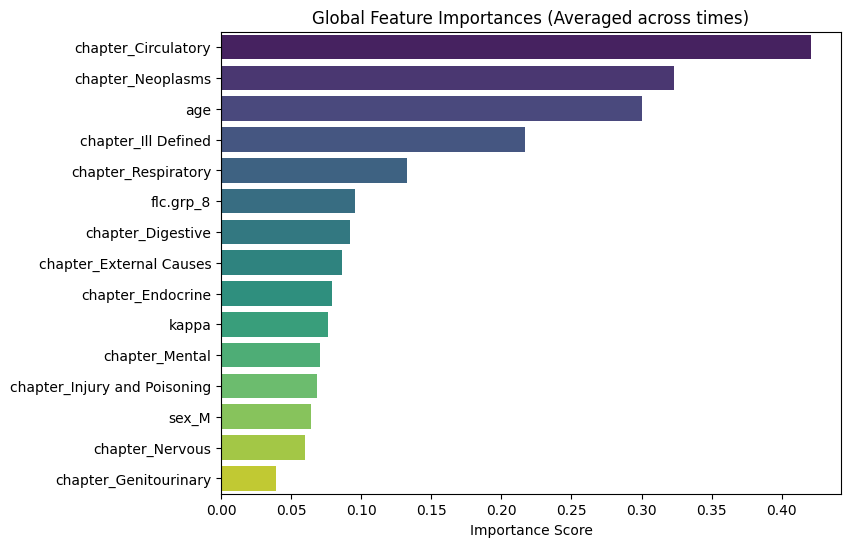

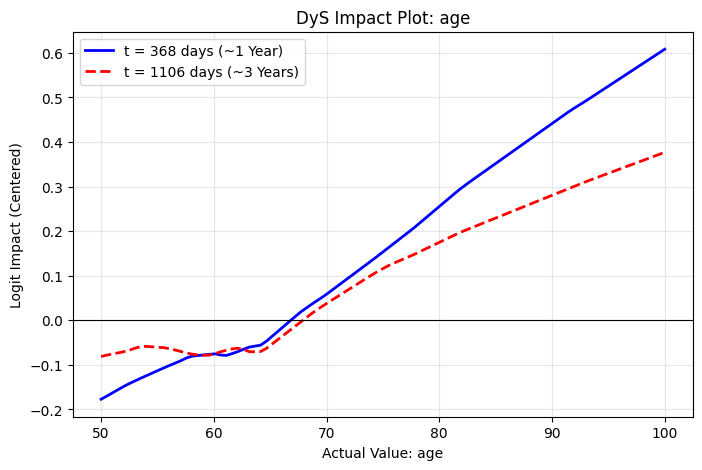

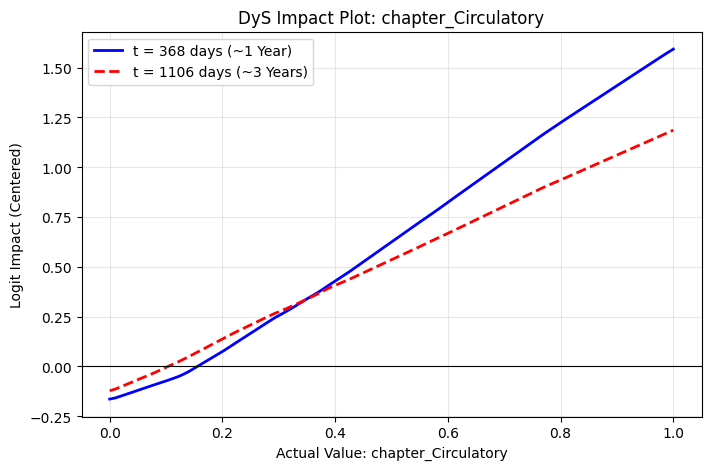

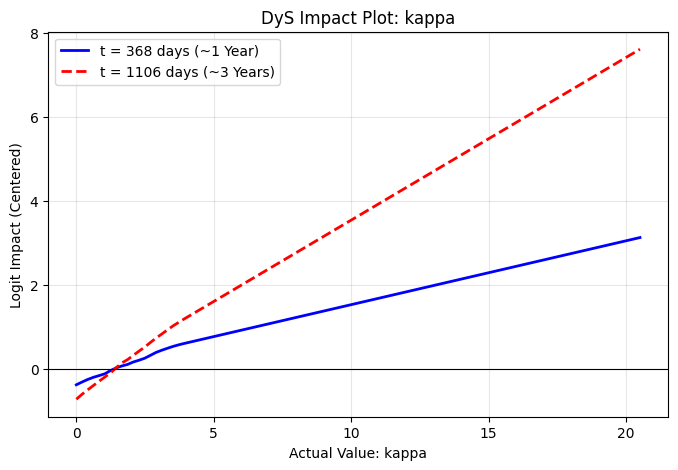

Error: Model does not contain activated Stage 2 (interactions).
Error: Model does not contain activated Stage 2 (interactions).


In [22]:
if cfg.dataset_name.lower() == "flchain":
    plot_feature_importance(model, x_t, feature_names)
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "age")
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "chapter_Circulatory")
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "kappa")
    
    plot_interaction_impact_heatmap(
        model=model, 
        x_train=x_t, 
        feature_names=feature_names, 
        eval_times=eval_times, 
        scaler=scaler, 
        feat1_name="age", 
        feat2_name="lambda", 
        target_days=365
    )
    plot_interaction_impact_heatmap(
        model=model, 
        x_train=x_t, 
        feature_names=feature_names, 
        eval_times=eval_times, 
        scaler=scaler, 
        feat1_name="kappa", 
        feat2_name="creatinine", 
        target_days=365
    )

elif cfg.dataset_name.lower() == "metabric":
    plot_feature_importance(model, x_t, feature_names)
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "age_at_diagnosis")
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "size")
    print(feature_names)

    plot_interaction_impact_heatmap(
        model=model, 
        x_train=x_t, 
        feature_names=feature_names, 
        eval_times=eval_times, 
        scaler=scaler, 
        feat1_name="age_at_diagnosis", 
        feat2_name="size", 
        target_days=365
    )
    plot_interaction_impact_heatmap(
        model=model, 
        x_train=x_t, 
        feature_names=feature_names, 
        eval_times=eval_times, 
        scaler=scaler, 
        feat1_name="size", 
        feat2_name="NPI", 
        target_days=365
    )



### Funkcja do walidacji modelu (Próby wielokrotne)
Ten blok zawiera zakomentowaną funkcję `run_staged_trials`, która automatyzuje uruchamianie serii niezależnych eksperymentów z różnymi losowymi podziałami danych (seeds). Pozwala ona ocenić stabilność i powtarzalność modelu DyS, obliczając średnią wartość (Mean AUC) oraz odchylenie standardowe (Std Dev) osobno dla pierwszego etapu (tylko efekty główne) oraz drugiego etapu (efekty główne + interakcje). Pokazuje również średni przyrost dokładności wynikający z dodania nieliniowych interakcji cech.

In [23]:
def run_staged_trials(
    dataset_name=cfg.dataset_name, num_trials=10, base_seed=42
):
    """Runs multiple training trials, tracking and displaying statistics

    for Stage 1 (Main Effects) completely before displaying Stage 2.
    """
    stage1_aucs = []
    stage2_aucs = []

    print(
        f"===== Running {num_trials} Trials for Dataset: {dataset_name} ====="
    )

    for trial in range(num_trials):
        trial_seed = base_seed + trial
        print(f"-> Training Trial {trial + 1}/{num_trials} (Seed: {trial_seed})...")

        # Set seeds for reproducibility
        torch.manual_seed(trial_seed)
        np.random.seed(trial_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(trial_seed)

        # Prepare dataset
        (
            (x_train, x_test, t_train, t_test, e_train, e_test),
            feature_names,
            scaler,
        ) = prepare_dataset(dataset_name, random_state=trial_seed)

        x_t = torch.tensor(x_train, dtype=torch.float32).to(cfg.device)
        t_t = torch.tensor(t_train, dtype=torch.float32).to(cfg.device)
        e_t = torch.tensor(e_train, dtype=torch.float32).to(cfg.device)
        eval_times = np.linspace(0, t_train.max(), cfg.k_bins)

        # Initialize and train model
        model = DySModel(len(feature_names), cfg.k_bins).to(cfg.device)
        model = train_dys(
            model=model,
            x_train=x_t,
            t_train=t_t,
            e_train=e_t,
            x_test=x_test,
            t_test=t_test,
            e_test=e_test,
            eval_times=eval_times,
            l_lambda=cfg.l_lambda,
            use_interactions=cfg.use_interactions,  # Runs both stages internally
        )

        # --- Capture Stage 1 Performance ---
        # Temporarily bypass interaction gates to isolate Main Effects
        original_interaction_gates = model.interaction_gates
        model.interaction_gates = None

        s1_auc = evaluate_auc(
            model, x_test, t_train, e_train, t_test, e_test, eval_times
        )
        stage1_aucs.append(s1_auc)

        # --- Capture Stage 2 Performance ---
        # Restore interaction gates to get full model performance
        model.interaction_gates = original_interaction_gates

        if cfg.use_interactions and original_interaction_gates is not None:
            s2_auc = evaluate_auc(
                model, x_test, t_train, e_train, t_test, e_test, eval_times
            )
            stage2_aucs.append(s2_auc)
        else:
            stage2_aucs.append(
                s1_auc
            )  # If interactions skipped, score remains same

    # --- Print Stage 1 Summary First ---
    print("\n" + "=" * 60)
    print(" STAGE 1 FINAL RESULTS (Main Effects Only)")
    print("=" * 60)
    print(f"Trial AUCs: {[round(x, 4) for x in stage1_aucs]}")
    print(f"• Mean AUC: {np.mean(stage1_aucs):.4f}")
    print(f"• Std Dev:  {np.std(stage1_aucs):.4f}")
    print("=" * 60)

    # --- Print Stage 2 Summary Second ---
    if cfg.use_interactions:
        print("\n" + "=" * 60)
        print(" STAGE 2 FINAL RESULTS (Main Effects + Interactions)")
        print("=" * 60)
        print(f"Trial AUCs: {[round(x, 4) for x in stage2_aucs]}")
        print(f"• Mean AUC: {np.mean(stage2_aucs):.4f}")
        print(f"• Std Dev:  {np.std(stage2_aucs):.4f}")
        print(
            f"• Average Improvement: {np.mean(stage2_aucs) - np.mean(stage1_aucs):.4f}"
        )
        print("=" * 60)

    return stage1_aucs, stage2_aucs

In [24]:
if(cfg.use_many_trials):
    stage1_results, stage2_results = run_staged_trials(
    dataset_name=cfg.dataset_name, 
    num_trials=10, 
    base_seed=42
)